#Libraries

In [ ]:
!pip install librosa

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Data preprocessing

In [ ]:
metadata = pd.read_csv("/content/drive/MyDrive/DS3 Files/UrbanSound8K/UrbanSound8K.csv")
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [ ]:
AUDIO_PATH = "/content/drive/MyDrive/DS3 Files/UrbanSound8K/"

metadata["file_path"] = metadata.apply(
    lambda row: os.path.join(
        AUDIO_PATH,
        f"fold{row['fold']}",
        row["slice_file_name"]
    ),
    axis=1
)

metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class,file_path
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark,/content/drive/MyDrive/DS3 Files/UrbanSound8K/...
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing,/content/drive/MyDrive/DS3 Files/UrbanSound8K/...
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing,/content/drive/MyDrive/DS3 Files/UrbanSound8K/...
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing,/content/drive/MyDrive/DS3 Files/UrbanSound8K/...
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing,/content/drive/MyDrive/DS3 Files/UrbanSound8K/...


In [ ]:
def extract_mel(file_path, max_len=128):
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=4)

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=128
        )

        mel_db = librosa.power_to_db(mel)

        # fix length
        if mel_db.shape[1] < max_len:
            pad_width = max_len - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0,0),(0,pad_width)))
        else:
            mel_db = mel_db[:, :max_len]

        return mel_db

    except:
        return None

#Turn .wav into spectrogram

In [ ]:
X = []
y = []

for i in range(len(metadata)):
    file_path = metadata.loc[i, "file_path"]
    label = metadata.loc[i, "class"]

    feature = extract_mel(file_path)

    if feature is not None:
        X.append(feature)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Shape:", X.shape)

# Only initially ran once, then saved both X and y as .npy files for faster training

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(


Shape: (8732, 128, 128)


In [ ]:
X = np.load("/content/drive/MyDrive/DS3 Files/X_mel.npy")
y = np.load("/content/drive/MyDrive/DS3 Files/y.npy")

print("Shape:", X.shape)

Shape: (8732, 128, 128, 1)


In [ ]:
X = (X - np.mean(X)) / np.std(X) #normalize

#Load into model

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
#X = X.squeeze(axis=-1) # remove the extra dimension from (samples, 128, 128, 1, 1) to (samples, 128, 128, 1)

In [ ]:
print(X.shape)

(8732, 128, 128, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(len(np.unique(y_encoded)), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,784,522 (10.62 MB)

 Trainable params: 2,783,050 (10.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.4026 - loss: 1.8224 - val_accuracy: 0.1380 - val_loss: 2.9011
Epoch 2/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.6397 - loss: 1.0846 - val_accuracy: 0.3572 - val_loss: 2.0899
Epoch 3/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.7321 - loss: 0.8049 - val_accuracy: 0.7813 - val_loss: 0.6363
Epoch 4/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7961 - loss: 0.6194 - val_accuracy: 0.8117 - val_loss: 0.5515
Epoch 5/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8442 - loss: 0.4717 - val_accuracy: 0.8901 - val_loss: 0.3617
Epoch 6/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8759 - loss: 0.3757 - val_accuracy: 0.8563 - val_loss: 0.4334
Epoch 7/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8933 - loss: 0.3207 - val_accuracy: 0.8849 - val_loss: 0.3699
Epoch 8/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9142 - loss: 0.2611 - val_a

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9210 - loss: 0.3768
Test Loss: 0.37675175070762634
Test Accuracy: 0.9210074543952942


#Save model and encoder

In [ ]:
model.save("mel_model4.h5")

In [ ]:
model.save("mel_model4.keras")

In [ ]:
import pickle

with open("label_encoder2.pkl", "wb") as f:
    pickle.dump(le, f)

#Metrics

In [ ]:
pred = model.predict(X_input)
print(pred)
print(np.argmax(pred))

In [ ]:
print(le.classes_)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
                  precision    recall  f1-score   support

 air_conditioner       0.99      0.92      0.95       200
        car_horn       0.96      0.92      0.94        86
children_playing       0.86      0.91      0.88       200
        dog_bark       0.90      0.90      0.90       200
        drilling       0.87      0.93      0.90       200
   engine_idling       0.95      0.94      0.95       200
        gun_shot       0.93      0.99      0.95        75
      jackhammer       0.97      0.91      0.94       200
           siren       0.95      0.95      0.95       186
    street_music       0.88      0.91      0.89       200

        accuracy                           0.92      1747
       macro avg       0.93      0.93      0.92      1747
    weighted avg       0.92      0.92      0.92      1747



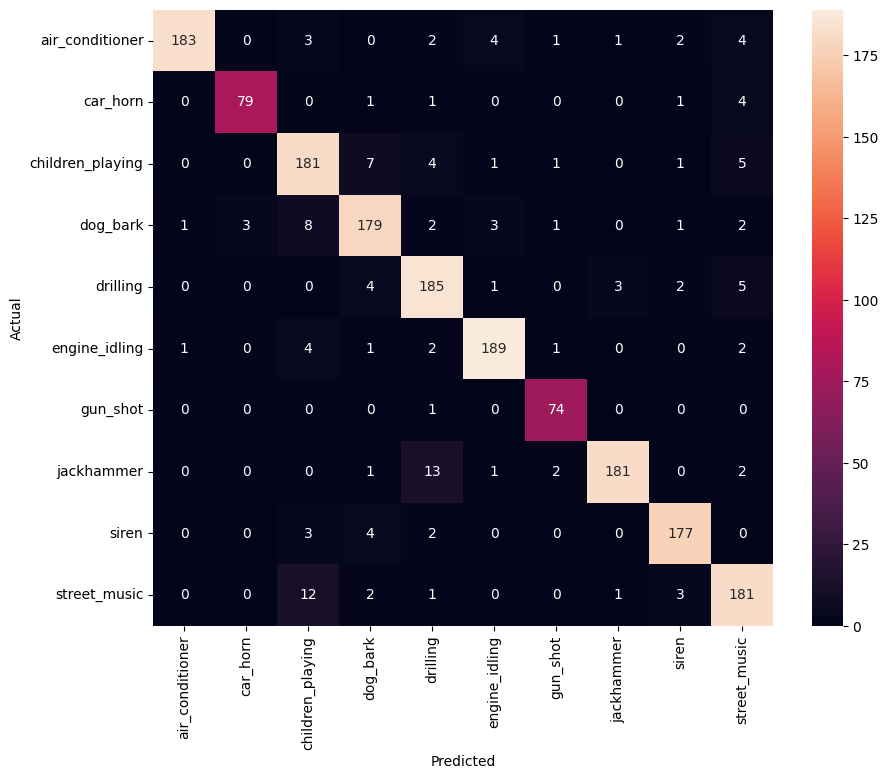

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

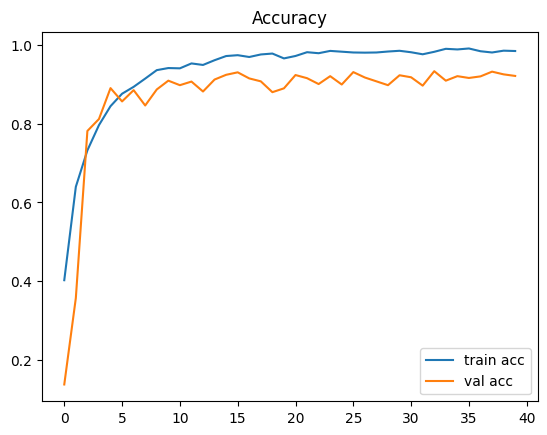

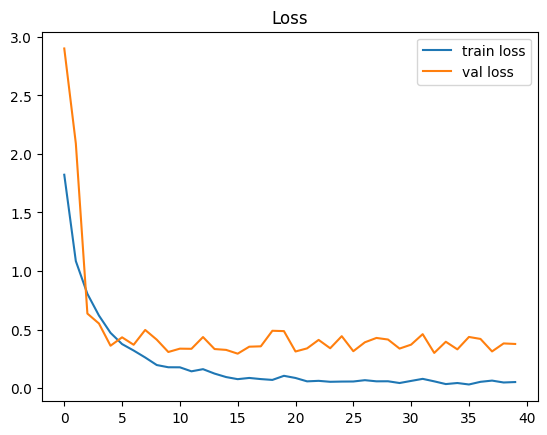

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()